In [21]:
import numpy as np
import h5py
from copy import deepcopy

import matplotlib.pyplot as plt
import corner
from matplotlib.lines import Line2D

from ml_stat import MLStatistic
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use("paper.mplstyle")
np.random.seed(0)

In [ ]:
# Training data file
input_files = [
    "../Files/LH_Samples_Flow.hdf"
]

# Saved flow model
model_file = "../Files/PHASE_TIME_AMP_L1H1_FLOW.h5"

group_name = "model"

# Plotting controls
n_flow_samples = 30000     # samples drawn from flow
max_data_plot  = 30000     # subsample training data for clarity
linear_sr = False          # convert log(sr) -> sr for plotting
wrap_phase = True          # wrap phase into [0, 2pi)

In [ ]:
#Load in the samples that were used to train the flow

def load_training_data(files):
    all_rows = []

    for file in files:
        data = {}
        with h5py.File(file, "r") as f:
            ifos = list(f.attrs["ifos"])
            ref_ifo = ifos[0]
            other_ifos = deepcopy(ifos)
            other_ifos.remove(ref_ifo)

            keys = []
            for ifo in other_ifos:
                keys.extend([
                    f"dt_{ifo}",
                    f"dp_{ifo}",
                    f"sr_{ifo}"
                ])

            for key in keys:
                data[key] = f[ref_ifo]["param_bin"][key][:]

        arr = np.array([data[k] for k in keys]).T
        all_rows.append(arr)

    data_array = np.vstack(all_rows)
    return data_array, ifos, keys


data, ifos, keys = load_training_data(input_files)
print(f"Loaded data shape: {data.shape}")
print("IFOs:", ifos)
print("Columns:", keys)

Loaded data shape: (500437, 3)
IFOs: ['L1', 'H1']
Columns: ['dt_H1', 'dp_H1', 'sr_H1']


In [ ]:
#Load in trained flow model

def load_model(model_file, group_name="model"):
    if hasattr(MLStatistic, "from_file"):
        return MLStatistic.from_file(model_file, group_name=group_name)
    elif hasattr(MLStatistic, "load"):
        return MLStatistic.load(model_file, group_name=group_name)
    else:
        raise RuntimeError("Cannot find MLStatistic loader method")


ml_stat = load_model(model_file, group_name)
flow = ml_stat.model

print(flow)

In [ ]:
#Draw samples from flow model

def draw_flow_samples(flow, n):
    for meth in ["sample", "rvs", "draw_samples", "generate"]:
        if hasattr(flow, meth):
            out = getattr(flow, meth)(n)
            if hasattr(out, "detach"):  # torch tensor
                out = out.detach().cpu().numpy()
            return np.asarray(out)
    raise RuntimeError("No sampling method found on flow")


flow_samples = draw_flow_samples(flow, n_flow_samples)
print("Flow samples shape:", flow_samples.shape)

Flow samples shape: (30000, 3)


In [ ]:
# Transformations if wanted for plotting

def transform_for_plot(x, linear_sr=True, wrap_phase=True):
    y = np.array(x, copy=True)
    n_dims = y.shape[1]

    for i in range(n_dims):
        if i % 3 == 1 and wrap_phase:   # phase
            y[:, i] = np.mod(y[:, i], 2 * np.pi)
        if i % 3 == 2 and linear_sr:    # log(sr) -> sr
            y[:, i] = np.exp(y[:, i])

    return y


# Subsample data for plotting
if data.shape[0] > max_data_plot:
    idx = np.random.choice(data.shape[0], max_data_plot, replace=False)
    data_plot = data[idx]
else:
    data_plot = data

data_plot = transform_for_plot(data_plot, linear_sr, wrap_phase)
flow_plot = transform_for_plot(flow_samples, linear_sr, wrap_phase)

In [ ]:
#Labels used on corner plots

ref_ifo = ifos[0]

labels = []
for k in keys:
    base, ifo = k.split("_")
    label = f"{base} {ref_ifo}{ifo}"

    labels.append(label)

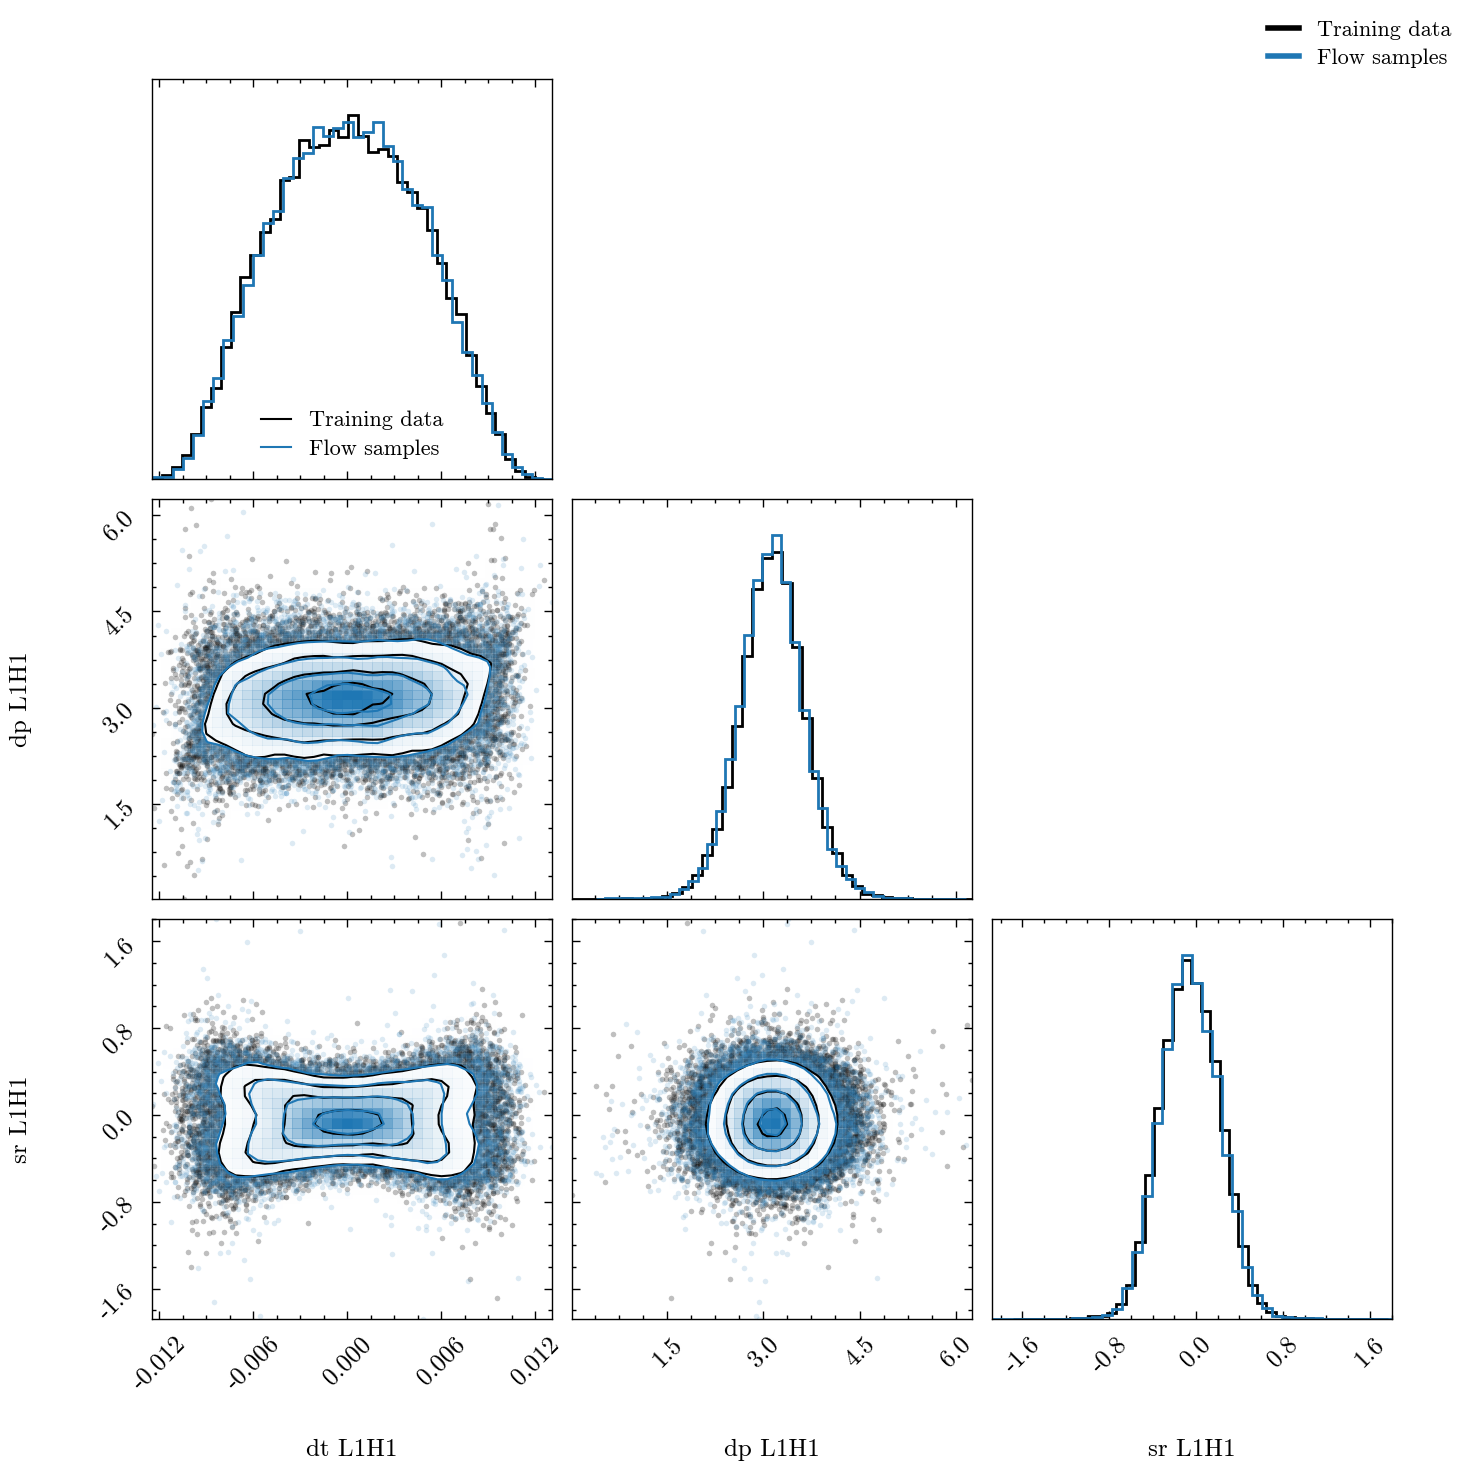

In [ ]:
#Plotting distribution of data vs flow model for comparison


fig = corner.corner(
    data_plot,
    labels=labels,
    show_titles=False,
    bins=40,
    smooth=0.8,
    plot_datapoints=True,
    fill_contours=False,
    color="black",
    data_kwargs={"alpha": 0.25},
    hist_kwargs={"density": True},
)

corner.corner(
    flow_plot,
    fig=fig,
    labels=labels,
    bins=40,
    smooth=0.8,
    plot_datapoints=True,
    fill_contours=False,
    color="tab:blue",
    data_kwargs={"alpha": 0.15},
    hist_kwargs={"density": True},
)


legend_elements = [
    Line2D([0], [0], color="black", lw=2, label="Training data"),
    Line2D([0], [0], color="tab:blue", lw=2, label="Flow samples"),
]

fig.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False
)
# Legend
ax0 = fig.axes[0]
ax0.plot([], [], color="black", label="Training data")
ax0.plot([], [], color="tab:blue", label="Flow samples")
ax0.legend(frameon=False)


plt.show()